# Band Power: EEG |FFT| Welch| Hilbert
 We start with a single sine wave, build intuition for what "power" means, learn four ways to measure it (FFT, Welch, Hilbert, Wavelet Transform), and then **confirm everything on real BrainBit & CalmSync data**.


In [32]:
# â”€â”€ Imports & style â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal
from scipy.signal import welch, hilbert
import json, warnings, sys
from pathlib import Path

warnings.filterwarnings('ignore')

# â”€â”€ Consistent style â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
plt.rcParams.update({
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor':   '#ffffff',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'figure.dpi':       110,
})

# palette
C_ALPHA  = '#e74c3c'   # red  â€” alpha band
C_THETA  = '#3498db'   # blue â€” theta band
C_SIGNAL = '#2c3e50'   # dark â€” raw signal
C_FP1    = '#2166ac'
C_FP2    = '#d6604d'

BAND_COLORS = {
    'Delta (1-4 Hz)':  '#9b59b6',
    'Theta (4-8 Hz)':  '#3498db',
    'Alpha (8-13 Hz)': '#e74c3c',
    'Beta (13-30 Hz)': '#2ecc71',
    'Gamma (30-40 Hz)':'#f39c12',
}

print("âœ“ Ready")

âœ“ Ready


---
## 1 Â· Power of a Sine Wave â€” The Intuition

> **Core idea:** Power = how much energy a signal carries at a given frequency.

A pure sine wave at frequency $f$ with amplitude $A$:

$$x(t) = A \sin(2\pi f \, t)$$

Its **power** is simply $\frac{A^2}{2}$. That's it. If $A = 1$, the power is **0.5**.

Let's see it.

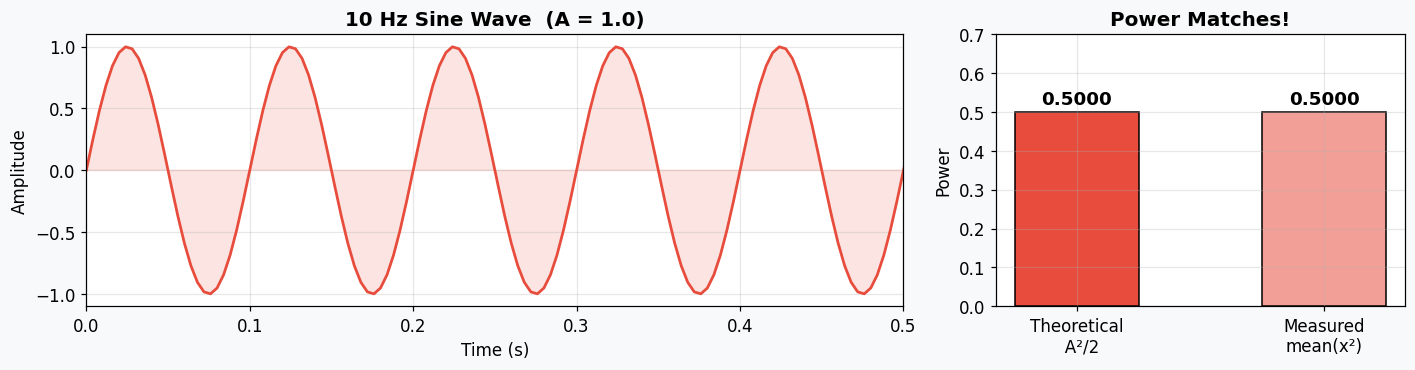

  Theoretical power = AÂ²/2 = 0.5
  Measured power    = mean(xÂ²) = 0.500000


In [33]:
# â”€â”€ A single 10 Hz sine wave â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fs   = 250                          # sampling rate (Hz) â€” same as BrainBit
dur  = 2                            # seconds
t    = np.arange(0, dur, 1/fs)
freq = 10                           # Hz (alpha band)
amp  = 1.0
sine = amp * np.sin(2 * np.pi * freq * t)

# theoretical power
theoretical_power = amp**2 / 2
measured_power    = np.mean(sine**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5), gridspec_kw={'width_ratios': [2, 1]})

# Left: the sine wave
ax = axes[0]
ax.plot(t, sine, color=C_ALPHA, lw=1.8)
ax.fill_between(t, sine, alpha=0.15, color=C_ALPHA)
ax.set(xlabel='Time (s)', ylabel='Amplitude', title=f'{freq} Hz Sine Wave  (A = {amp})')
ax.set_xlim(0, 0.5)

# Right: power bar
ax = axes[1]
bars = ax.bar(['Theoretical\n  AÂ²/2', 'Measured\nmean(xÂ²)'],
              [theoretical_power, measured_power],
              color=[C_ALPHA, '#e74c3c88'], edgecolor='k', width=0.5)
for bar, val in zip(bars, [theoretical_power, measured_power]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=12)
ax.set(ylabel='Power', title='Power Matches!', ylim=(0, 0.7))

plt.tight_layout()
plt.show()
print(f"  Theoretical power = AÂ²/2 = {theoretical_power}")
print(f"  Measured power    = mean(xÂ²) = {measured_power:.6f}")

**Takeaway:** Power is just the *average squared amplitude*. For a pure sine, it's exactly $A^2/2$.

But real EEG has **many frequencies mixed together**. We need methods that can tease apart *how much power lives at each frequency*. That's what PSD (Power Spectral Density) gives us.




## 2 Â· Methods to Compute Band Power



### 2a Â· FFT â€” The Foundation

> **Idea:** DFast Fourier Transform (FFT) is an efficient algorithm that decomposes a time-domain signal into its constituent complex sinusoidal components by computing the discrete correlation (inner product) between the signal and complex exponentials e^(i2Ï€ft) at each frequency bin. The resulting complex coefficients encode both the amplitude and phase of each frequency component present in the signal


**Assumptions** The Fourier Transform assumes that the signal is stationary, meaning its statistical properties (such as mean and variance) do not change over time.
**Pros:** Direct, no parameters to tune, shows you exactly what frequencies are present.  
**Cons:** Entire signal treated as one epoch. 


![FFT](images\FFT.jpeg)

In [34]:
# â”€â”€ Raw FFT (periodogram) on the pure 10 Hz sine â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
N    = len(sine)
freqs_fft = np.fft.rfftfreq(N, 1/fs)
fft_vals  = np.fft.rfft(sine)
psd_fft   = (2.0 / (N * fs)) * np.abs(fft_vals)**2   # one-sided PSD


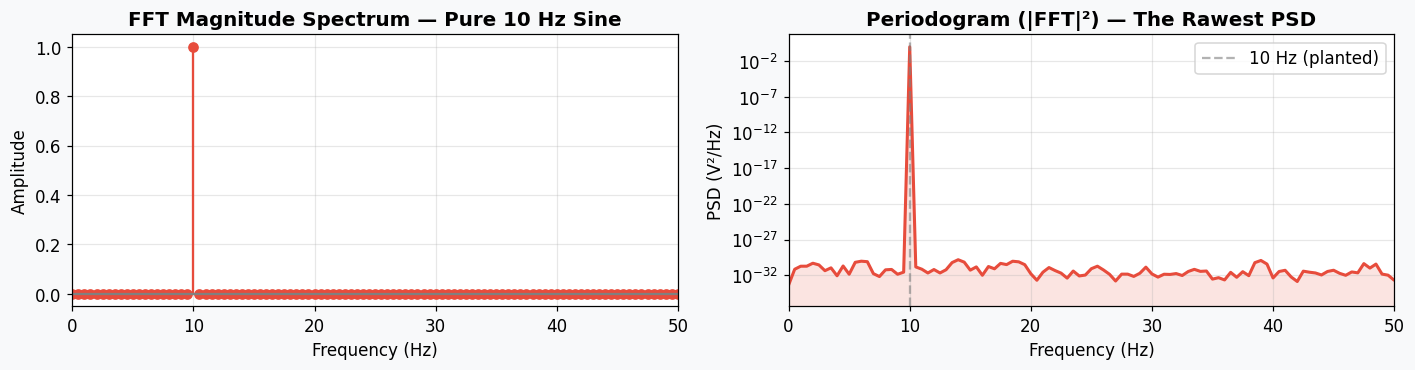

  â†’ Clean sine = clean spike. But on noisy signals this periodogram gets very jagged.
    That's why we need Welch / Multitaper to smooth it.


In [35]:
# â”€â”€ Raw FFT (periodogram) on the pure 10 Hz sine â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
N    = len(sine)
freqs_fft = np.fft.rfftfreq(N, 1/fs)
fft_vals  = np.fft.rfft(sine)
psd_fft   = (2.0 / (N * fs)) * np.abs(fft_vals)**2   # one-sided PSD



fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

# Left: magnitude spectrum (linear)
ax = axes[0]
ax.stem(freqs_fft, np.abs(fft_vals) * 2/N, linefmt=C_ALPHA, markerfmt='o', basefmt='grey')
ax.set(xlabel='Frequency (Hz)', ylabel='Amplitude',
       title='FFT Magnitude Spectrum â€” Pure 10 Hz Sine', xlim=(0, 50))

# Right: periodogram (log scale, like a PSD)
ax = axes[1]
ax.semilogy(freqs_fft, psd_fft, color=C_ALPHA, lw=2)
ax.fill_between(freqs_fft, psd_fft, alpha=0.15, color=C_ALPHA)
ax.axvline(10, ls='--', color='grey', alpha=0.6, label='10 Hz (planted)')
ax.set(xlabel='Frequency (Hz)', ylabel='PSD (VÂ²/Hz)',
       title='Periodogram (|FFT|Â²) â€” The Rawest PSD', xlim=(0, 50))
ax.legend()

plt.tight_layout()
plt.show()
print("  â†’ Clean sine = clean spike. But on noisy signals this periodogram gets very jagged.")
print("    That's why we need Welch / Multitaper to smooth it.")



### 2b Â· Welch's Method 

> **Idea:** Chop the signal into overlapping windows â†’ compute FFT on each â†’ average the periodograms.

**Pros:** Simple, robust, smooth estimate.  
**Cons:** No time resolution â€” gives you one spectrum for the whole segment.

Parameters: nperseg , nooverlap

In [36]:
# â”€â”€ Welch on a pure 10 Hz sine â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
freqs_w, psd_w = welch(sine, fs=fs, nperseg=256, noverlap=128)


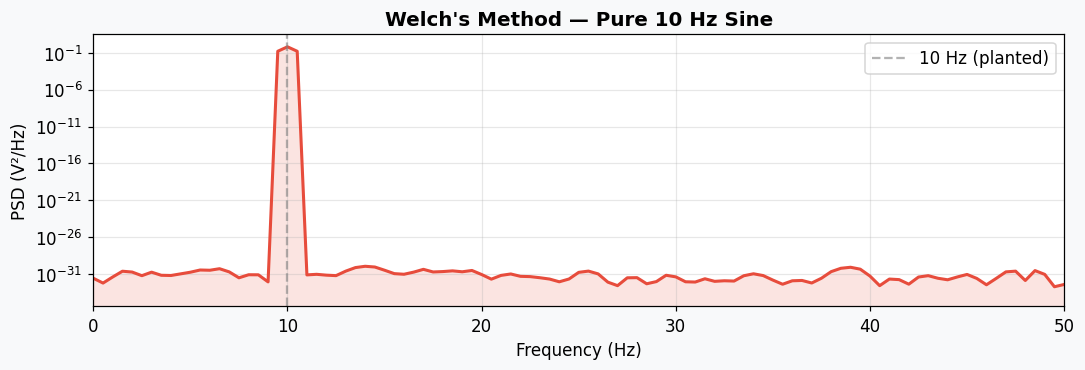

  â†’ Sharp peak exactly at 10 Hz. Welch correctly finds all the power there.


In [37]:
# â”€â”€ Welch on a pure 10 Hz sine â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
freqs_w, psd_w = welch(sine, fs=fs, nperseg=960, noverlap=480)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.semilogy(freqs_w, psd_w, color=C_ALPHA, lw=2)
ax.axvline(10, ls='--', color='grey', alpha=0.6, label='10 Hz (planted)')
ax.fill_between(freqs_w, psd_w, alpha=0.15, color=C_ALPHA)
ax.set(xlabel='Frequency (Hz)', ylabel='PSD (VÂ²/Hz)',
       title="Welch's Method â€” Pure 10 Hz Sine", xlim=(0, 50))
ax.legend()
plt.tight_layout()
plt.show()
print("  â†’ Sharp peak exactly at 10 Hz. Welch correctly finds all the power there.")

Example: At 240 Hz, a 2-second segment = 480 samples. To detect 0.1 Hz, you'd need 10 seconds of data (one full cycle) â€” but your window is only 2 seconds. The lowest frequency you can resolve is 1 / 2s = 0.5 Hz. 

### 2c Â· Hilbert Transform (instantaneous power)
The Hilbert Transform lets you turn a real signal into a rotating complex signal so that amplitude and phase become measurable at every instant in time. 

> **Idea:** Compute the analytic signal â†’ its envelope gives *instantaneous amplitude* at each time point.  
> Bandpass-filter first, then apply Hilbert to get power **over time** within that band.

**Pros:** Time-resolved â€” you can see power fluctuate moment by moment.  
**Cons:** Requires bandpass filtering first.
![Hilbert's Formula](images\hilberttransform.png)

Hilbert Transform â€” Visual Walkthrough

> **Idea:** The Hilbert transform takes a real signal and produces an **analytic signal** â€” a complex version where:
> - **Real part** = original signal
> - **Imaginary part** = every frequency shifted by âˆ’90Â°
>
> From this we extract **instantaneous amplitude**, **power**, and **phase** at every time point.

$$z(t) = x(t) + j\,\hat{x}(t)$$

Let's see it on a simple mixed signal.


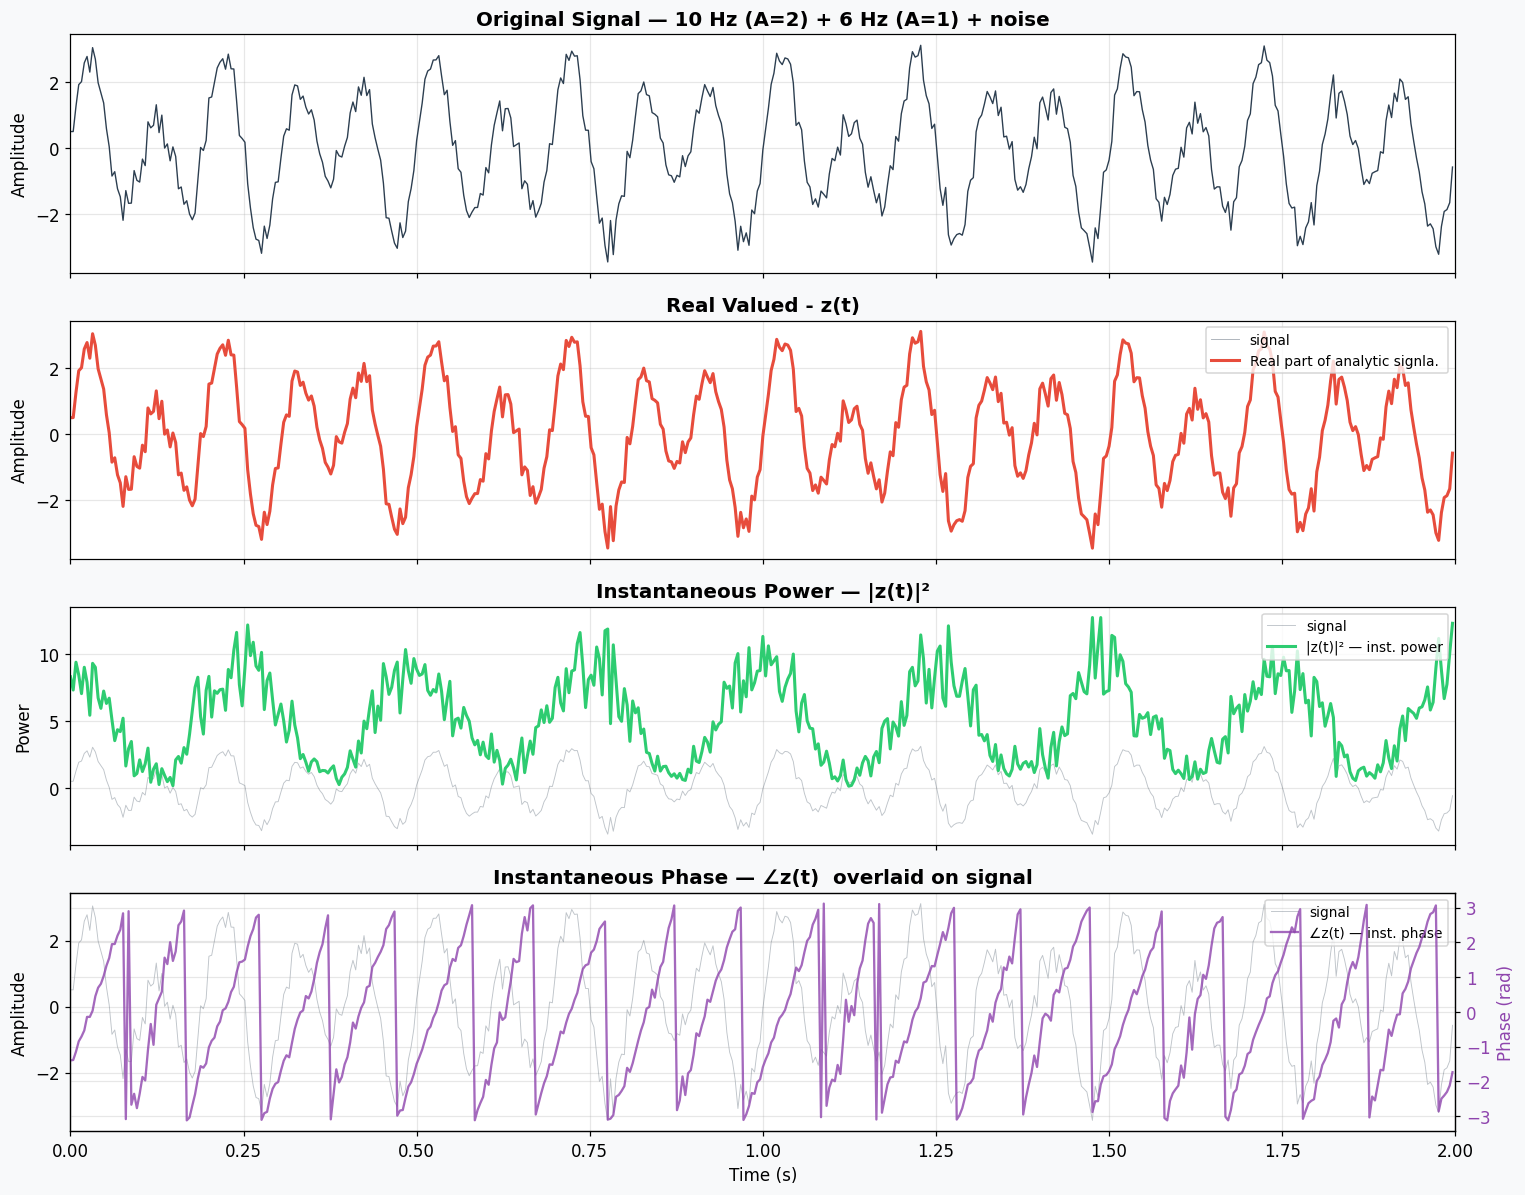

  Mean instantaneous amplitude: 2.14
  Mean instantaneous power:     5.12


In [58]:
# â”€â”€ Build a simple mixed signal â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
np.random.seed(7)
fs_h   = 250
t_h    = np.arange(0, 2, 1/fs_h)

# 10 Hz (A=2) + 6 Hz (A=1) + noise
sig = 2.0*np.sin(2*np.pi*10*t_h) + 1.0*np.sin(2*np.pi*6*t_h) + 0.3*np.random.randn(len(t_h))

# â”€â”€ Hilbert â†’ analytic signal â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
z         = hilbert(sig)             # analytic signal (complex)
real_z = np.real(z)
inst_amp  = np.abs(z)                # instantaneous amplitude  |z(t)|
inst_pow  = inst_amp ** 2            # instantaneous power      |z(t)|Â²
inst_phase = (np.angle(z))  # instantaneous phase      âˆ z(t)

# â”€â”€ Plot â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)

# 1) Original signal
ax = axes[0]
ax.plot(t_h, sig, color=C_SIGNAL, lw=0.9)
ax.set(ylabel='Amplitude', title='Original Signal â€” 10 Hz (A=2) + 6 Hz (A=1) + noise')

# 2) Amp 
ax = axes[1]
ax.plot(t_h, np.real(z), color=C_SIGNAL, lw=0.6, alpha=0.4, label='signal')
ax.plot(t_h, sig, color='#e74c3c', lw=2, label='Real part of analytic signla. ')
ax.set(ylabel='Amplitude', title='Real Valued - z(t)')
ax.legend(fontsize=9, loc='upper right')

# 3) Instantaneous power
ax = axes[2]
ax.plot(t_h, real_z, color=C_SIGNAL, lw=0.6, alpha=0.3, label='signal')
ax.plot(t_h, inst_pow, color='#2ecc71', lw=2, label='|z(t)|Â² â€” inst. power')
ax.set(ylabel='Power', title='Instantaneous Power â€” |z(t)|Â²')
ax.legend(fontsize=9, loc='upper right')


# 4) Instantaneous phase overlaid on signal
ax = axes[3]
ax_phase = ax.twinx()
ax.plot(t_h, sig, color=C_SIGNAL, lw=0.6, alpha=0.3, label='signal')
ax_phase.plot(t_h, inst_phase, color='#8e44ad', lw=1.5, alpha=0.8, label='âˆ z(t) â€” inst. phase')
ax.set(xlabel='Time (s)', ylabel='Amplitude')
ax_phase.set_ylabel('Phase (rad)', color='#8e44ad')
ax_phase.tick_params(axis='y', labelcolor='#8e44ad')
ax.set_title('Instantaneous Phase â€” âˆ z(t)  overlaid on signal')

# combine legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_phase.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')

for a in axes:
    a.set_xlim(0, 2)

plt.tight_layout()
plt.show()

print(f"  Mean instantaneous amplitude: {inst_amp.mean():.2f}")
print(f"  Mean instantaneous power:     {inst_pow.mean():.2f}")


### 2d Â· Wavelet Transform (time-frequency decomposition)

> **Idea:** Convolve the signal with Morlet wavelets at each frequency of interest. Each wavelet is a short oscillation windowed by a Gaussian, giving you power at a specific frequency *and* time point.

**Pros:** Full time-frequency resolution â€” see which frequencies are active and *when*. Natural for non-stationary signals like EEG.  
**Cons:** Trade-off between time and frequency resolution (controlled by `n_cycles`). More computationally expensive than Welch.

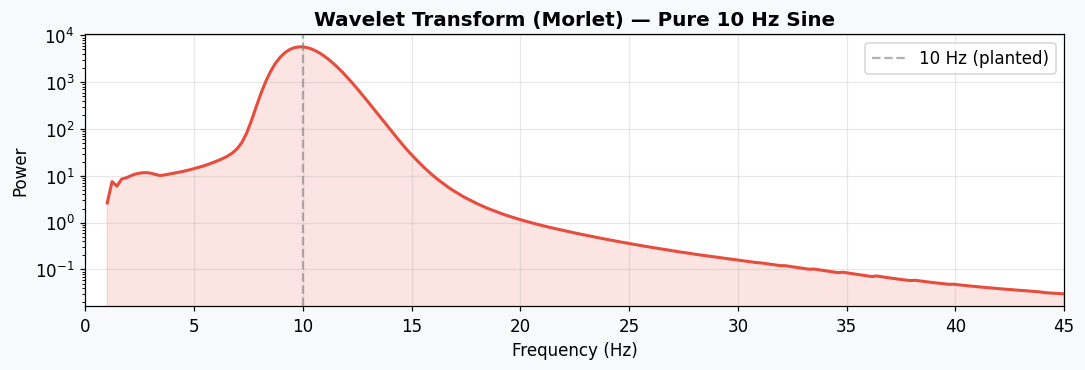

  â†’ Morlet wavelet also finds the 10 Hz peak. Width of the peak reflects the time-frequency trade-off.


In [39]:
# â”€â”€ Wavelet helper: Morlet wavelet PSD â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def wavelet_psd(x, fs, freqs=None, n_cycles=7):
    """Estimate PSD using Morlet wavelet transform.
    Returns (freqs, psd) analogous to scipy.signal.welch."""
    if freqs is None:
        freqs = np.linspace(1, fs/2 - 1, 200)
    # psd = np.zeros(len(freqs))
    # for i, freq in enumerate(freqs):
    #     sigma_t = n_cycles / (2 * np.pi * freq)
    #     n_pts = int(6 * sigma_t * fs)
    #     if n_pts % 2 == 0:
    #         n_pts += 1
    #     t_wav = np.arange(-n_pts // 2, n_pts // 2 + 1) / fs
    #     wavelet = (np.exp(2j * np.pi * freq * t_wav)
    #                * np.exp(-t_wav**2 / (2 * sigma_t**2)))
    #     wavelet /= np.sqrt(sigma_t * np.sqrt(np.pi))
    #     conv = np.convolve(x, wavelet, mode='same')
    #     psd[i] = np.mean(np.abs(conv) ** 2)
    # return freqs, psd

# â”€â”€ Wavelet on the pure 10 Hz sine â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# freqs_wav, psd_wav = wavelet_psd(sine, fs, freqs=np.linspace(1, 45, 200))


import pywt
freqs = np.linspace(1, fs/2 - 1, 200)
scales = 7 * fs / (2 * np.pi * freqs)  # convert freqs â†’ scales
coeffs, _ = pywt.cwt(sine, scales, 'cmor1.5-1.0', sampling_period=1/fs)
psd = np.mean(np.abs(coeffs)**2, axis=1)  # power at each scale


fig, ax = plt.subplots(figsize=(10, 3.5))
ax.semilogy(freqs_wav, psd_wav, color=C_ALPHA, lw=2)
ax.axvline(10, ls='--', color='grey', alpha=0.6, label='10 Hz (planted)')
ax.fill_between(freqs_wav, psd_wav, alpha=0.15, color=C_ALPHA)
ax.set(xlabel='Frequency (Hz)', ylabel='Power',
       title='Wavelet Transform (Morlet) â€” Pure 10 Hz Sine', xlim=(0, 45))
ax.legend()
plt.tight_layout()
plt.show()
print("  â†’ Morlet wavelet also finds the 10 Hz peak. Width of the peak reflects the time-frequency trade-off.")

---
## 3 Â· Synthetic Signal

We build a signal where we **know the ground truth**:
- **10 Hz** (alpha) with amplitude **2.0**
- **6 Hz** (theta) with amplitude **1.0**
- Gaussian noise (Ïƒ = 0.5)

Expected power: Î± = $2^2/2 = 2.0$, Î¸ = $1^2/2 = 0.5$.

Now we apply all three methods and see if they **rediscover** what we planted.

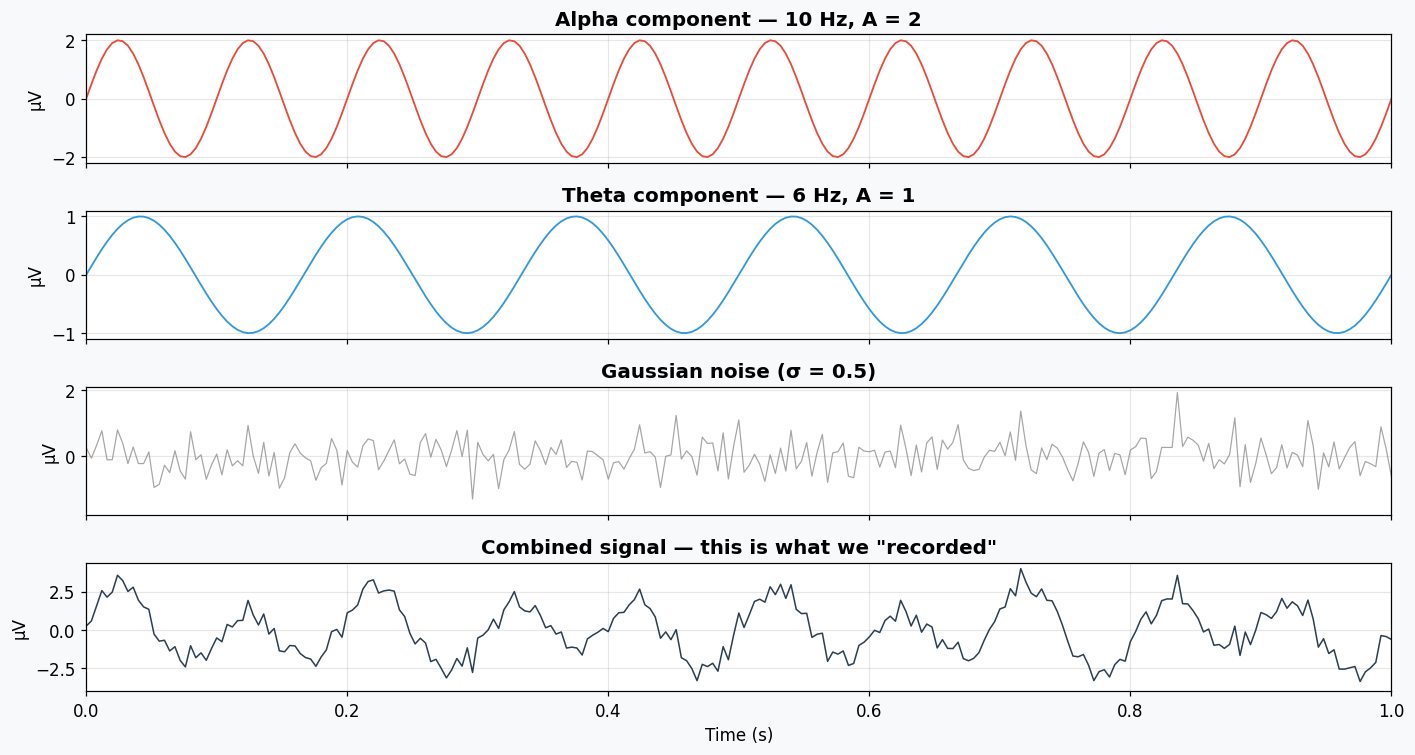

  Ground truth â†’ Alpha power = 2.0,  Theta power = 0.5


In [40]:
# â”€â”€ Build synthetic EEG-like signal â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
np.random.seed(42)
fs_synth = 250
dur_synth = 4                              # seconds (enough for good resolution)
t_synth = np.arange(0, dur_synth, 1/fs_synth)

alpha_comp = 2.0 * np.sin(2 * np.pi * 10 * t_synth)   # 10 Hz, A=2
theta_comp = 1.0 * np.sin(2 * np.pi *  6 * t_synth)   #  6 Hz, A=1
noise      = 0.5 * np.random.randn(len(t_synth))

synth = alpha_comp + theta_comp + noise

# â”€â”€ Visualise components â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(4, 1, figsize=(13, 7), sharex=True)

axes[0].plot(t_synth, alpha_comp, color=C_ALPHA, lw=1.2)
axes[0].set(ylabel='ÂµV', title='Alpha component â€” 10 Hz, A = 2')
axes[0].set_xlim(0, 1)

axes[1].plot(t_synth, theta_comp, color=C_THETA, lw=1.2)
axes[1].set(ylabel='ÂµV', title='Theta component â€” 6 Hz, A = 1')

axes[2].plot(t_synth, noise, color='grey', lw=0.8, alpha=0.7)
axes[2].set(ylabel='ÂµV', title='Gaussian noise (Ïƒ = 0.5)')

axes[3].plot(t_synth, synth, color=C_SIGNAL, lw=1)
axes[3].set(xlabel='Time (s)', ylabel='ÂµV', title='Combined signal â€” this is what we "recorded"')

for ax in axes:
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()
print("  Ground truth â†’ Alpha power = 2.0,  Theta power = 0.5")

### 3a Â· All Four Methods Side by Side on the Synthetic Signal

In [41]:
# â”€â”€ Helper: band power from PSD â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def bandpower_from_psd(freqs, psd, fmin, fmax):
    """Integrate PSD between fmin and fmax using the trapezoidal rule."""
    mask = (freqs >= fmin) & (freqs <= fmax)
    return np.trapz(psd[mask], freqs[mask])

# â”€â”€ EEG frequency bands â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
BANDS = {
    'Delta (1-4 Hz)':   (1,  4),
    'Theta (4-8 Hz)':   (4,  8),
    'Alpha (8-13 Hz)':  (8,  13),
    'Beta (13-30 Hz)':  (13, 30),
    'Gamma (30-40 Hz)': (30, 40),
}

# â”€â”€ Compute PSDs â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# FFT (raw periodogram)
N_synth    = len(synth)
freqs_fft  = np.fft.rfftfreq(N_synth, 1/fs_synth)
psd_fft    = (2.0 / (N_synth * fs_synth)) * np.abs(np.fft.rfft(synth))**2

# Welch
fw, pw = welch(synth, fs=fs_synth, nperseg=512, noverlap=256)

# Wavelet
fwav, pwav = wavelet_psd(synth, fs_synth, freqs=np.linspace(1, 45, 200))

# â”€â”€ Hilbert per-band power â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def hilbert_band_power(x, fs, fmin, fmax):
    """Bandpass â†’ Hilbert â†’ mean instantaneous power."""
    sos = signal.butter(4, [fmin, fmax], btype='band', fs=fs, output='sos')
    filtered = signal.sosfiltfilt(sos, x)
    return np.mean(np.abs(hilbert(filtered))**2)

# â”€â”€ Grand comparison figure â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig = plt.figure(figsize=(15, 9))
gs  = gridspec.GridSpec(2, 4, height_ratios=[1.2, 1], hspace=0.35, wspace=0.3)

# Row 1: PSD curves â€” FFT, Welch, Wavelet, Hilbert
psd_panels = [
    (freqs_fft, psd_fft, "FFT (raw periodogram)"),
    (fw, pw, "Welch"),
    (fwav, pwav, "Wavelet (Morlet)"),
]

for col, (f, p, title) in enumerate(psd_panels):
    ax = fig.add_subplot(gs[0, col])
    mask = f <= 45
    ax.semilogy(f[mask], p[mask], color=C_SIGNAL, lw=1.5)
    for bname, (lo, hi) in BANDS.items():
        bmask = (f >= lo) & (f <= hi) & (f <= 45)
        ax.fill_between(f[bmask], p[bmask], alpha=0.35, color=BAND_COLORS[bname],
                        label=bname if col == 0 else None)
    ax.axvline(6,  ls='--', color=C_THETA, alpha=0.5)
    ax.axvline(10, ls='--', color=C_ALPHA, alpha=0.5)
    ax.set(xlabel='Frequency (Hz)', ylabel='PSD (VÂ²/Hz)', title=title, xlim=(0, 45))
    if col == 0:
        ax.legend(fontsize=7, loc='upper right')

# Hilbert time-resolved panel
ax = fig.add_subplot(gs[0, 3])
for bname, (lo, hi) in [('Theta (4-8 Hz)', (4, 8)), ('Alpha (8-13 Hz)', (8, 13))]:
    sos = signal.butter(4, [lo, hi], btype='band', fs=fs_synth, output='sos')
    filt = signal.sosfiltfilt(sos, synth)
    env  = np.abs(hilbert(filt))**2
    ax.plot(t_synth, env, lw=1.5, color=BAND_COLORS[bname], label=bname, alpha=0.85)
ax.set(xlabel='Time (s)', ylabel='Inst. power', title='Hilbert (time-resolved)', xlim=(0, dur_synth))
ax.legend(fontsize=8)

# Row 2: Bar chart comparison across all 4 methods
ax = fig.add_subplot(gs[1, :])
methods = ['FFT', 'Welch', 'Wavelet', 'Hilbert']
x_pos   = np.arange(len(BANDS))
width   = 0.2

for i, method in enumerate(methods):
    powers = []
    for bname, (lo, hi) in BANDS.items():
        if method == 'FFT':
            powers.append(bandpower_from_psd(freqs_fft, psd_fft, lo, hi))
        elif method == 'Welch':
            powers.append(bandpower_from_psd(fw, pw, lo, hi))
        elif method == 'Wavelet':
            powers.append(bandpower_from_psd(fwav, pwav, lo, hi))
        else:
            powers.append(hilbert_band_power(synth, fs_synth, lo, hi))
    ax.bar(x_pos + i*width, powers, width, label=method, alpha=0.85)

ax.set_xticks(x_pos + 1.5*width)
ax.set_xticklabels(BANDS.keys(), fontsize=9)
ax.set(ylabel='Band Power (VÂ²)', title='Band Power Comparison â€” All Four Methods Agree')
ax.legend()

ax.annotate('Ground truth:\nÎ± = 2.0, Î¸ = 0.5', xy=(0.75, 0.85), xycoords='axes fraction',
            fontsize=10, fontweight='bold', color='#555',
            bbox=dict(boxstyle='round,pad=0.4', fc='#ffffcc', alpha=0.9))

plt.tight_layout()
plt.show()

TypeError: cannot unpack non-iterable NoneType object

**Key takeaway:** All four methods find the alpha peak at 10 Hz and theta at 6 Hz â€” exactly what we planted. The bar chart shows they agree on band power values. Now let's see what happens with **real brain data**.

---
## 4 Â· Real Data: BrainBit & CalmSync

We load continuous EEG from both devices, apply the same four methods, and see what the **actual brain** looks like compared to our synthetic signal.

**Devices:**
| | BrainBit | CalmSync |
|---|----------|----------|
| Channels | Fp1, Fp2 | Fp1, Fp2 |
| Sampling rate | ~250 Hz | ~240 Hz |
| Format | XDF (LSL) | JSON |

In [64]:
# â”€â”€ Load BrainBit (XDF) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import pyxdf

xdf_path = r"C:\Users\bwsin\Desktop\Osis_data\Data\Brainbit\Archi_27febgoodbadimages.xdf"
streams, _ = pyxdf.load_xdf(xdf_path)

eeg_stream = None
for s in streams:
    if s['info']['type'][0].lower() == 'eeg' and len(s['time_stamps']) > 0:
        eeg_stream = s
        break

raw_data = np.array(eeg_stream['time_series']).T
eeg_ts   = np.array(eeg_stream['time_stamps'])

bb_fs = float(1.0 / np.median(np.diff(eeg_ts - eeg_ts[0])))

BB_CHAN_NAMES = ['Fz', 'F3', 'Cz', 'F4', 'Pz', 'Fp1', 'Fp2', 'Oz']
fp1_idx = BB_CHAN_NAMES.index('Fp1')
fp2_idx = BB_CHAN_NAMES.index('Fp2')

# Volts â†’ ÂµV, remove DC offset
bb_fp1 = raw_data[fp1_idx, :].astype(float) * 1e6
bb_fp2 = raw_data[fp2_idx, :].astype(float) * 1e6
bb_fp1 -= bb_fp1.mean()
bb_fp2 -= bb_fp2.mean()

# â”€â”€ Load CalmSync (JSON) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
json_path = r"C:\Users\bwsin\Desktop\Osis_data\Data\Calmsync\eeg_2026-02-27T16-33-22_2026-02-27T16-36-16.json"
with open(json_path) as f:
    cs_json = json.load(f)

cs_fs  = cs_json['samplingRateHz']
cs_raw = np.array(cs_json['data'], dtype=float)

cs_fp1 = ((cs_raw[0] - 512) * 3.3 / 1024) / 1100 * 1e6
cs_fp2 = ((cs_raw[1] - 512) * 3.3 / 1024) / 1100 * 1e6

# â”€â”€ Bandpass + Notch filter â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def preprocess(x, fs, hp=0.1, lp=45.0, notch=50.0):
    sos_bp = signal.butter(4, [hp, lp], btype='band', fs=fs, output='sos')
    x = signal.sosfiltfilt(sos_bp, x)
    b, a = signal.iirnotch(notch, Q=30, fs=fs)
    x = signal.filtfilt(b, a, x)
    x -= x.mean()
    return x

bb_fp1 = preprocess(bb_fp1, bb_fs)
bb_fp2 = preprocess(bb_fp2, bb_fs)
cs_fp1 = preprocess(cs_fp1, cs_fs)
cs_fp2 = preprocess(cs_fp2, cs_fs)

print(f"  BrainBit: {len(bb_fp1)} samples, fs = {bb_fs:.1f} Hz, {len(bb_fp1)/bb_fs:.1f} s")
print(f"  CalmSync: {len(cs_fp1)} samples, fs = {cs_fs:.1f} Hz, {len(cs_fp1)/cs_fs:.1f} s")


  BrainBit: 45440 samples, fs = 249.6 Hz, 182.0 s
  CalmSync: 41646 samples, fs = 239.7 Hz, 173.7 s


### 4a Â· Raw Signal Preview (first 5 seconds)

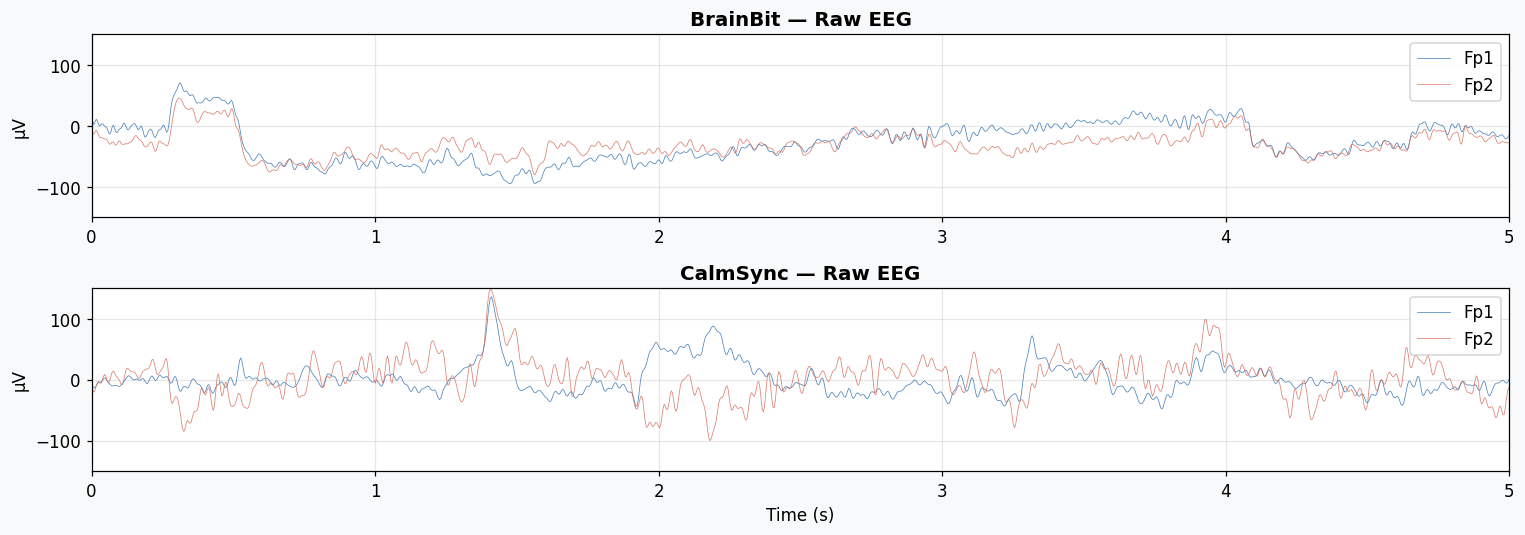

In [66]:
# â”€â”€ Quick look at raw signals â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=False)

t_bb = np.arange(len(bb_fp1)) / bb_fs
t_cs = np.arange(len(cs_fp1)) / cs_fs

axes[0].plot(t_bb, bb_fp1, color=C_FP1, lw=0.5, alpha=0.8, label='Fp1')
axes[0].plot(t_bb, bb_fp2, color=C_FP2, lw=0.5, alpha=0.8, label='Fp2')
axes[0].set(ylabel='ÂµV', title='BrainBit â€” Raw EEG', xlim=(0, 5))
axes[0].set_ylim(-150, 150)
axes[0].legend(loc='upper right')

axes[1].plot(t_cs, cs_fp1, color=C_FP1, lw=0.5, alpha=0.8, label='Fp1')
axes[1].plot(t_cs, cs_fp2, color=C_FP2, lw=0.5, alpha=0.8, label='Fp2')
axes[1].set(xlabel='Time (s)', ylabel='ÂµV', title='CalmSync â€” Raw EEG', xlim=(0, 5))
axes[1].set_ylim(-150, 150)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()


### 4b Â· Welch PSD â€” BrainBit vs CalmSync (Fp1)

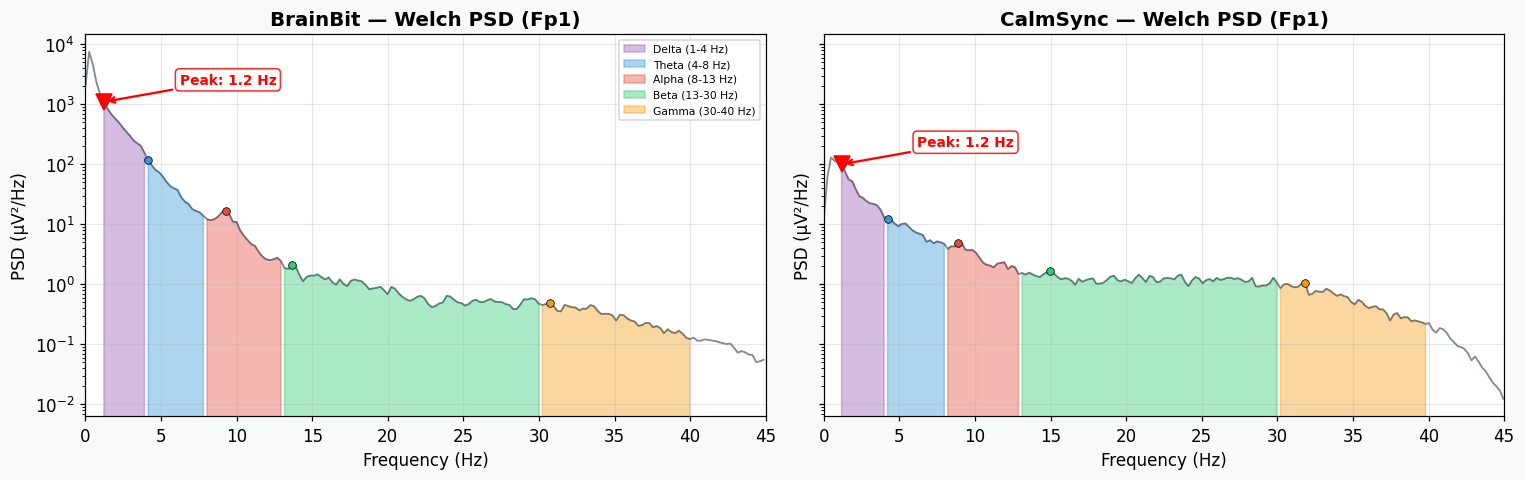

Band Power Summary  (BrainBit: 182s,  CalmSync: 174s)

  Device             Band  Band Power (ÂµVÂ²)  Relative (%)  Peak Freq (Hz)
BrainBit   Delta (1-4 Hz)           1220.29          82.6            1.22
BrainBit   Theta (4-8 Hz)            164.48          11.1            4.14
BrainBit  Alpha (8-13 Hz)             38.91           2.6            9.26
BrainBit  Beta (13-30 Hz)             13.79           0.9           13.65
BrainBit Gamma (30-40 Hz)              2.91           0.2           30.72
CalmSync   Delta (1-4 Hz)            103.76          58.4            1.17
CalmSync   Theta (4-8 Hz)             29.01          16.3            4.21
CalmSync  Alpha (8-13 Hz)             13.85           7.8            8.90
CalmSync  Beta (13-30 Hz)             20.65          11.6           14.98
CalmSync Gamma (30-40 Hz)              5.49           3.1           31.84


In [67]:
# â”€â”€ Welch PSD for both devices â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

for ax, (data, fs_dev, name) in zip(axes, [
    (bb_fp1, bb_fs, 'BrainBit'),
    (cs_fp1, cs_fs, 'CalmSync'),
]):
    f, p = welch(data, fs=fs_dev, nperseg=1024, noverlap=512)
    mask = f <= 45
    f, p = f[mask], p[mask]

    ax.semilogy(f, p, color=C_SIGNAL, lw=1.2, alpha=0.6)
    for bname, (lo, hi) in BANDS.items():
        bmask = (f >= lo) & (f <= hi)
        ax.fill_between(f[bmask], p[bmask], alpha=0.4, color=BAND_COLORS[bname], label=bname)

    # â”€â”€ Peak frequency marker (just the dot, no bracket text) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    valid = f >= 1
    peak_idx = np.argmax(p[valid])
    peak_freq = f[valid][peak_idx]
    peak_psd  = p[valid][peak_idx]

    ax.plot(peak_freq, peak_psd, 'v', color='red', markersize=10, zorder=5)
    ax.annotate(f'Peak: {peak_freq:.1f} Hz',
                xy=(peak_freq, peak_psd),
                xytext=(peak_freq + 5, peak_psd * 2),
                fontsize=9, fontweight='bold', color='red',
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='red', alpha=0.85))

    # Per-band peak dots
    for bname, (lo, hi) in BANDS.items():
        bmask = (f >= lo) & (f <= hi)
        if bmask.any():
            bp_idx = np.argmax(p[bmask])
            ax.plot(f[bmask][bp_idx], p[bmask][bp_idx], 'o',
                    color=BAND_COLORS[bname], markersize=5, zorder=4,
                    markeredgecolor='k', markeredgewidth=0.5)

    ax.set(xlabel='Frequency (Hz)', title=f'{name} â€” Welch PSD (Fp1)', xlim=(0, 45))

axes[0].set_ylabel('PSD (ÂµVÂ²/Hz)')
axes[1].set_ylabel('PSD (ÂµVÂ²/Hz)')
axes[0].legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

# â”€â”€ Band power table â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
rows = []
for data, fs_dev, name in [(bb_fp1, bb_fs, 'BrainBit'), (cs_fp1, cs_fs, 'CalmSync')]:
    f, p = welch(data, fs=fs_dev, nperseg=1024, noverlap=512)
    duration = len(data) / fs_dev

    # total power (1-45 Hz)
    total_mask = (f >= 1) & (f <= 45)
    total_power = np.trapz(p[total_mask], f[total_mask])

    for bname, (lo, hi) in BANDS.items():
        bmask = (f >= lo) & (f <= hi)
        band_power = np.trapz(p[bmask], f[bmask])
        peak_freq  = f[bmask][np.argmax(p[bmask])]
        pct = 100 * band_power / total_power
        rows.append({
            'Device': name,
            'Band': bname,
            'Band Power (ÂµVÂ²)': round(band_power, 2),
            'Relative (%)': round(pct, 1),
            'Peak Freq (Hz)': round(peak_freq, 2),
        })

df = pd.DataFrame(rows)
print(f"Band Power Summary  (BrainBit: {len(bb_fp1)/bb_fs:.0f}s,  CalmSync: {len(cs_fp1)/cs_fs:.0f}s)\n")
print(df.to_string(index=False))


### 4c Â· Wavelet PSD â€” BrainBit vs CalmSync (Fp1)

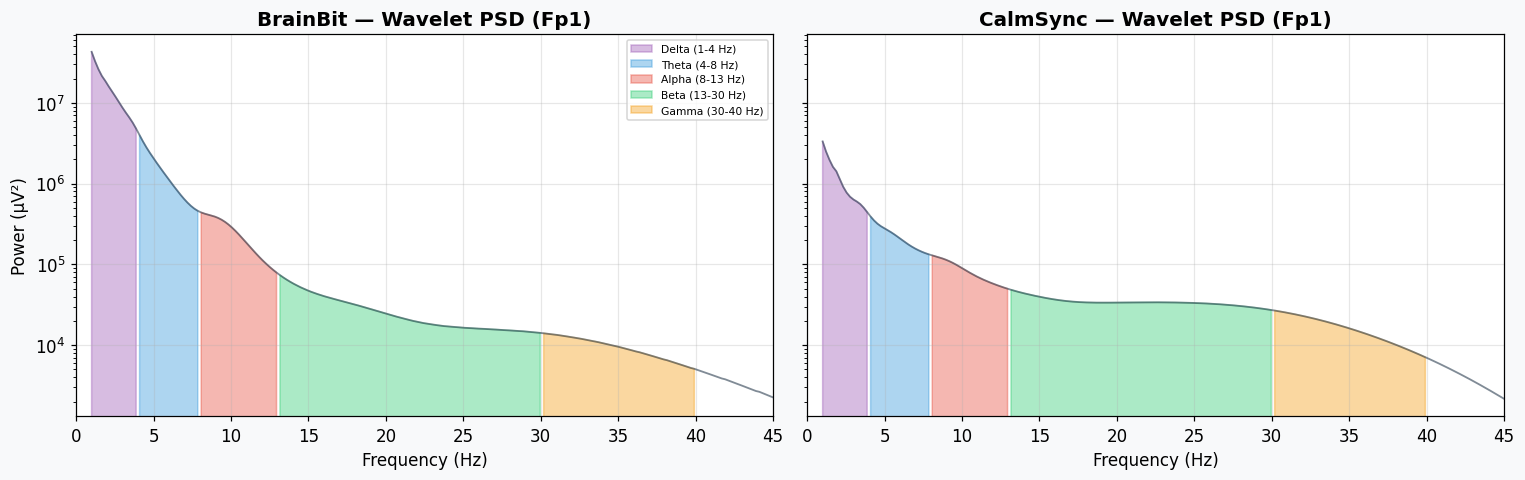

In [ ]:
# â”€â”€ Wavelet PSD for both devices â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

for ax, (data, fs_dev, name) in zip(axes, [
    (bb_fp1, bb_fs, 'BrainBit'),
    (cs_fp1, cs_fs, 'CalmSync'),
]):
    f, p = wavelet_psd(data, fs_dev, freqs=np.linspace(1, 45, 200))

    ax.semilogy(f, p, color=C_SIGNAL, lw=1.2, alpha=0.6)
    for bname, (lo, hi) in BANDS.items():
        bmask = (f >= lo) & (f <= hi)
        ax.fill_between(f[bmask], p[bmask], alpha=0.4, color=BAND_COLORS[bname], label=bname)
    ax.set(xlabel='Frequency (Hz)', title=f'{name} â€” Wavelet PSD (Fp1)', xlim=(0, 45))

axes[0].set_ylabel('Power (ÂµVÂ²)')
axes[0].legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

### 4d Â· Hilbert â€” Time-Resolved Band Power (first 30 seconds)

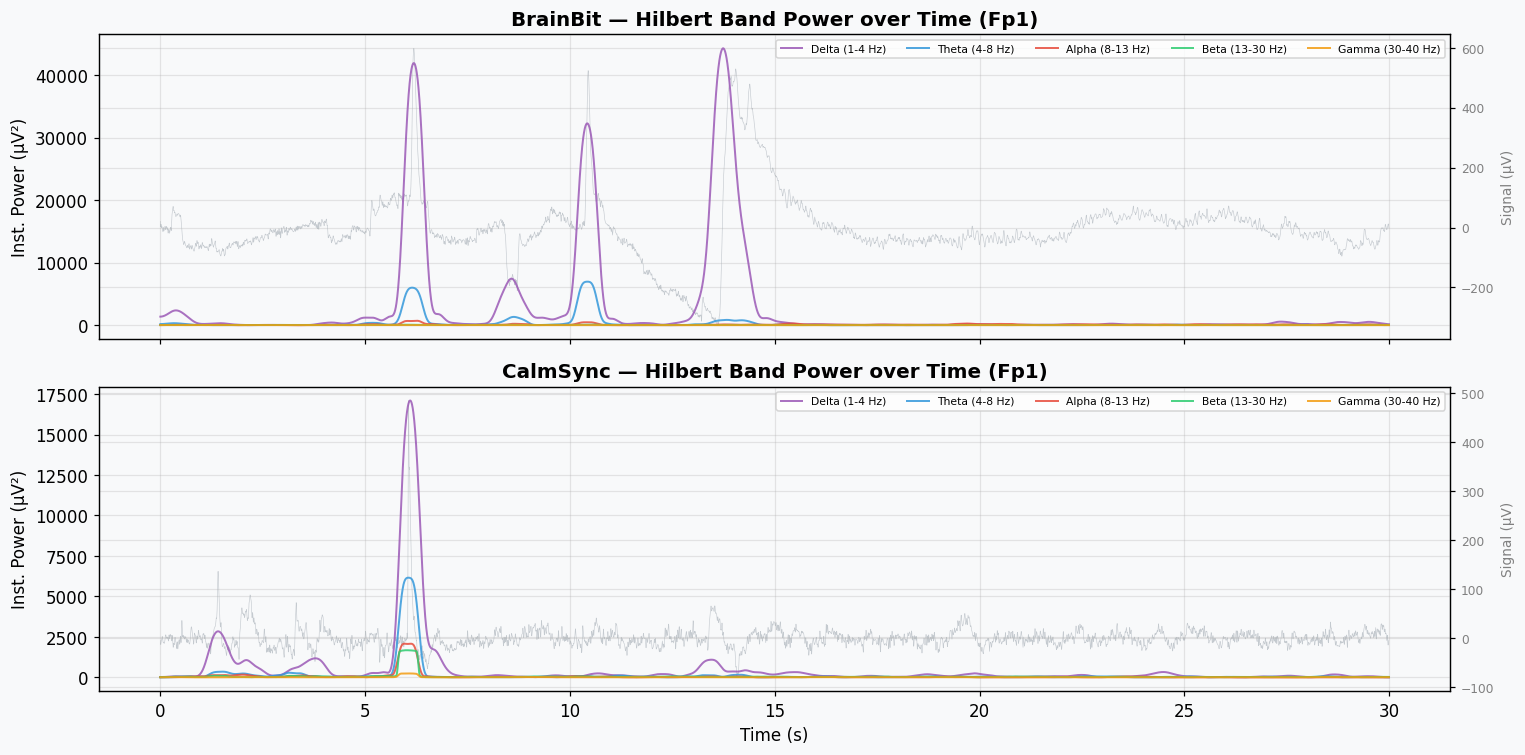

Hilbert Band Power Summary (first 30s, Fp1)

  Device             Band  Mean Power (ÂµVÂ²)  Relative (%)  Peak Power (ÂµVÂ²)  Peak Time (s)  Std (ÂµVÂ²)
BrainBit   Delta (1-4 Hz)           2817.69          86.5          74193.45           6.19    9788.42
BrainBit   Theta (4-8 Hz)            316.44           9.7          14954.63          10.42    1447.42
BrainBit  Alpha (8-13 Hz)             91.34           2.8           1810.28           6.13     150.96
BrainBit  Beta (13-30 Hz)             24.11           0.7            337.55           8.71      31.32
BrainBit Gamma (30-40 Hz)              6.57           0.2             88.86           2.90       8.84
CalmSync   Delta (1-4 Hz)            534.72          65.2          30246.97           6.09    2515.47
CalmSync   Theta (4-8 Hz)            149.34          18.2          14011.21           6.07    1008.04
CalmSync  Alpha (8-13 Hz)             63.68           7.8           6012.94           6.04     381.50
CalmSync  Beta (13-30 Hz)      

In [68]:
# â”€â”€ Hilbert time-resolved band power + raw signal overlay â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from scipy.ndimage import uniform_filter1d
import pandas as pd

def hilbert_envelope(x, fs, fmin, fmax):
    """Return instantaneous power time series for a band."""
    sos = signal.butter(4, [fmin, fmax], btype='band', fs=fs, output='sos')
    filt = signal.sosfiltfilt(sos, x)
    return np.abs(hilbert(filt))**2

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
window = 30  # show first 30 seconds

rows = []

for ax, (data, fs_dev, name) in zip(axes, [
    (bb_fp1, bb_fs, 'BrainBit'),
    (cs_fp1, cs_fs, 'CalmSync'),
]):
    n_samp = int(window * fs_dev)
    t_plot = np.arange(n_samp) / fs_dev

    # raw signal on a twin axis (behind everything)
    ax_sig = ax.twinx()
    ax_sig.plot(t_plot, data[:n_samp], color=C_SIGNAL, lw=0.4, alpha=0.25, zorder=0)
    ax_sig.set_ylabel('Signal (ÂµV)', color='grey', fontsize=9)
    ax_sig.tick_params(axis='y', labelcolor='grey', labelsize=8)

    # band power curves on top + collect stats
    band_means = {}
    for bname, (lo, hi) in BANDS.items():
        env = hilbert_envelope(data[:n_samp], fs_dev, lo, hi)
        env_smooth = uniform_filter1d(env, size=int(0.5*fs_dev))
        ax.plot(t_plot, env_smooth, lw=1.3, color=BAND_COLORS[bname], label=bname, alpha=0.85, zorder=2)

        mean_pow = env.mean()
        peak_pow = env.max()
        peak_time = t_plot[np.argmax(env)]
        band_means[bname] = mean_pow

        rows.append({
            'Device': name,
            'Band': bname,
            'Mean Power (ÂµVÂ²)': round(mean_pow, 2),
            'Peak Power (ÂµVÂ²)': round(peak_pow, 2),
            'Peak Time (s)': round(peak_time, 2),
            'Std (ÂµVÂ²)': round(env.std(), 2),
        })

    # relative % for this device
    total = sum(band_means.values())
    for r in rows:
        if r['Device'] == name and 'Relative (%)' not in r:
            r['Relative (%)'] = round(100 * r['Mean Power (ÂµVÂ²)'] / total, 1)

    ax.set(ylabel='Inst. Power (ÂµVÂ²)', title=f'{name} â€” Hilbert Band Power over Time (Fp1)')
    ax.legend(fontsize=7, loc='upper right', ncol=5)
    ax.set_zorder(ax_sig.get_zorder() + 1)
    ax.patch.set_visible(False)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

# â”€â”€ Summary table â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
df = pd.DataFrame(rows)
col_order = ['Device', 'Band', 'Mean Power (ÂµVÂ²)', 'Relative (%)', 'Peak Power (ÂµVÂ²)', 'Peak Time (s)', 'Std (ÂµVÂ²)']
df = df[col_order]
print(f"Hilbert Band Power Summary (first {window}s, Fp1)\n")
print(df.to_string(index=False))

# â”€â”€ Deductions â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print("\n--- Observations ---\n")
for name in ['BrainBit', 'CalmSync']:
    sub = df[df['Device'] == name]
    dominant = sub.loc[sub['Mean Power (ÂµVÂ²)'].idxmax()]
    most_variable = sub.loc[sub['Std (ÂµVÂ²)'].idxmax()]
    print(f"  {name}:")
    print(f"    Dominant band:       {dominant['Band']}  ({dominant['Relative (%)']}% of total power)")
    print(f"    Most variable band:  {most_variable['Band']}  (std = {most_variable['Std (ÂµVÂ²)']} ÂµVÂ²)")
    print(f"    Strongest burst:     {dominant['Band']} at t = {dominant['Peak Time (s)']}s  ({dominant['Peak Power (ÂµVÂ²)']} ÂµVÂ²)")

    # alpha/theta ratio
    alpha_pow = sub[sub['Band'].str.contains('Alpha')]['Mean Power (ÂµVÂ²)'].values[0]
    theta_pow = sub[sub['Band'].str.contains('Theta')]['Mean Power (ÂµVÂ²)'].values[0]
    ratio = alpha_pow / theta_pow if theta_pow > 0 else float('inf')
    state = "relaxed/alert" if ratio > 1 else "drowsy/unfocused"
    print(f"    Alpha/Theta ratio:   {ratio:.2f}  â†’ suggests {state}")
    print()


---
## 5 Â· Summary & Method Cheat Sheet

| Method | What it gives you | Time resolution? | Best for |
|--------|-------------------|:-:|----------|
| **FFT** | Raw periodogram | No (whole segment) | Seeing exact frequency content |
| **Welch** | Smooth PSD estimate | No (whole segment) | Quick spectral overview |
| **Hilbert** | Instantaneous power per band | **Yes** | Tracking power changes over time |
| **Wavelet** | Time-frequency power map | **Yes** | Non-stationary signals, seeing when frequencies come and go |

### Key Takeaways

1. **Power = mean squared amplitude.** For a sine wave: $A^2/2$. Simple.
2. **All four methods agree** on band power â€” they just have different trade-offs.
3. **Real EEG follows 1/f** â€” power drops with frequency (unlike our flat synthetic signal).
4. **Relative band power** lets you compare across devices with different amplifier scales.
5. **Hilbert is unique** â€” it gives you *time-resolved* power, so you can watch bands fluctuate moment to moment.
6. **Wavelet transform** gives you the full time-frequency picture â€” you can see both *which* frequencies and *when* they are active.

---
*Notebook created for the OSIS Lab â€” Band Power Lecture*